In [1]:
### CELL - 1 ###

# Step 1: Import fundamental libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
### CELL - 2 ###

# Step 2: Load the dataset from your Excel file
# Replace 'your_dataset.xlsx' with your exact file name
# Cell 2 inside your Movie_Sentiment_Recommendation.ipynb:
df = pd.read_csv('movies_dataset.csv')

# Display the first 5 rows to verify the data loaded properly
df.head(10)


,movie_title,release_year,genre,rating,description,review,sentiment
0,The Shawshank Redemption,1994,Drama,9.3,Two imprisoned men bond over a number of years...,An absolute masterpiece of cinema. The storyte...,1
1,The Godfather,1972,"Crime, Drama",9.2,The aging patriarch of an organized crime dyna...,The greatest crime movie ever made. Flawless a...,1
2,The Dark Knight,2008,"Action, Crime",9.0,When the menace known as the Joker wreaks havo...,"Ledger's Joker is legendary. A dark, intense, ...",1
3,The Godfather Part II,1974,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,"A rare sequel that matches, if not surpasses, ...",1
4,12 Angry Men,1957,"Crime, Drama",9.0,The jury in a New York City boy's mutiny trial...,An incredible study of human psychology and te...,1
5,Schindler's List,1993,"Biography, Drama",9.0,"In German-occupied Poland during World War II,...","Heartbreaking, powerful, and essential viewing...",1
6,The Lord of the Rings: The Return of the King,2003,"Action, Adventure",9.0,Gandalf and Aragorn lead the World of Men agai...,The perfect conclusion to an epic trilogy. The...,1
7,Pulp Fiction,1994,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",Tarantino's dialogue is iconic and sharp. Comp...,1
8,Inception,2010,"Action, Sci-Fi",8.8,A thief who steals corporate secrets through t...,"Mind-bending visuals and a stunning, complex n...",1
9,Fight Club,1999,Drama,8.8,An insomniac office worker and a devil-may-car...,"Edgy, thought-provoking, and features one of t...",1


In [3]:
# Step 2: Define a sample dataset for training and demonstration

"""
positive_reviews = {
    'movie_title': ['The Dark Knight', 'Inception', 'Interstellar', 'The Conjuring', 'Insidious', 'Superbad', 'The Hangover', 'Toy Story', 'Finding Nemo', 'Avatar'],
    'genre': ['Action', 'Sci-Fi', 'Sci-Fi', 'Horror', 'Horror', 'Comedy', 'Comedy', 'Animation', 'Animation', 'Sci-Fi'],
    'review': [
        'An absolute masterpiece! Incredible performance as the Joker. Brilliant plot and action.',
        'Mind-bending visuals and amazing concept. Absolutely loved the dream architecture.',
        'A beautiful emotional masterpiece about space travel. The music score is outstanding.',
        'Terrifying and atmospheric. Easily one of the best horror movies with great jump scares.',
        'Very creepy and suspenseful. The atmosphere kept me on the edge of my seat.',
        'Hilarious from start to finish. The chemistry between the actors is amazing.',
        'A wild and funny ride! Extremely entertaining with unforgettable jokes and characters.',
        'Heartwarming and beautifully animated. A timeless masterpiece for children and adults.',
        'A wonderful underwater adventure. Beautiful colors and lovely characters.',
        'Visually stunning with groundbreaking effects. The world-building is incredible.'
    ],
    'sentiment': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]  # 1 represents Positive
}

negative_reviews = {
    'movie_title': ['The Last Airbender', 'Transformers 2', 'Epic Movie', 'The Room', 'Sharknado', 'Catwoman', 'Batman and Robin', 'Dragonball Evolution', 'The Mummy 2017', 'Jaws Revenge'],
    'genre': ['Action', 'Sci-Fi', 'Comedy', 'Drama', 'Horror', 'Action', 'Action', 'Action', 'Horror', 'Horror'],
    'review': [
        'Terrible adaptation. The acting was horrible and completely ruined the source material.',
        'Too loud, confusing plot, and mindless explosions. A massive disappointment.',
        'Unfunny, lazy jokes, and a complete waste of time. Do not watch this garbage.',
        'An absolute disaster of a script. The acting is incredibly stiff and makes no sense.',
        'Ridiculous plot, terrible special effects, and laughably bad acting.',
        'Awful storyline, terrible CGI costume, and completely boring experience.',
        'Cringey dialogue, over-the-top acting, and silly plot points.',
        'A complete insult to the fans. Bad choreography and horribly butchered plot.',
        'Boring, generic action with no real scares or charm. Waste of budget.',
        'Stupid plot, terrible mechanical shark effects, completely lacks suspense.'
    ],
    'sentiment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  # 0 represents Negative
}

# Combine into a single structured DataFrame
df = pd.DataFrame({
    'movie_title': positive_reviews['movie_title'] + negative_reviews['movie_title'],
    'genre': positive_reviews['genre'] + negative_reviews['genre'],
    'review': positive_reviews['review'] + negative_reviews['review'],
    'sentiment': positive_reviews['sentiment'] + negative_reviews['sentiment']
})

# Display first few rows
df.head()
"""

"\npositive_reviews = {\n    'movie_title': ['The Dark Knight', 'Inception', 'Interstellar', 'The Conjuring', 'Insidious', 'Superbad', 'The Hangover', 'Toy Story', 'Finding Nemo', 'Avatar'],\n    'genre': ['Action', 'Sci-Fi', 'Sci-Fi', 'Horror', 'Horror', 'Comedy', 'Comedy', 'Animation', 'Animation', 'Sci-Fi'],\n    'review': [\n        'An absolute masterpiece! Incredible performance as the Joker. Brilliant plot and action.',\n        'Mind-bending visuals and amazing concept. Absolutely loved the dream architecture.',\n        'A beautiful emotional masterpiece about space travel. The music score is outstanding.',\n        'Terrifying and atmospheric. Easily one of the best horror movies with great jump scares.',\n        'Very creepy and suspenseful. The atmosphere kept me on the edge of my seat.',\n        'Hilarious from start to finish. The chemistry between the actors is amazing.',\n        'A wild and funny ride! Extremely entertaining with unforgettable jokes and characters.',

In [4]:
### CELL - 3 ###

# Step 3: Inspect dataset properties
print("--- Dataset Info ---")
df.info()
print("\n--- Columns List ---")
print(df.columns)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_title   100 non-null    str    
 1   release_year  100 non-null    int64  
 2   genre         100 non-null    str    
 3   rating        100 non-null    float64
 4   description   100 non-null    str    
 5   review        100 non-null    str    
 6   sentiment     100 non-null    int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 29.9 KB

--- Columns List ---
Index(['movie_title', 'release_year', 'genre', 'rating', 'description',
       'review', 'sentiment'],
      dtype='str')


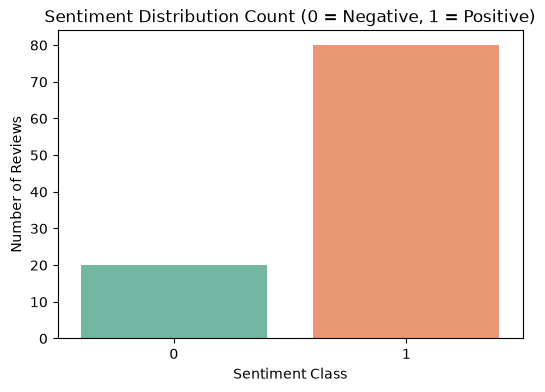

In [5]:
### CELL - 4 ###

# Step 4: Data Graph - Target Class Countplot
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution Count (0 = Negative, 1 = Positive)')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Reviews')
plt.show()

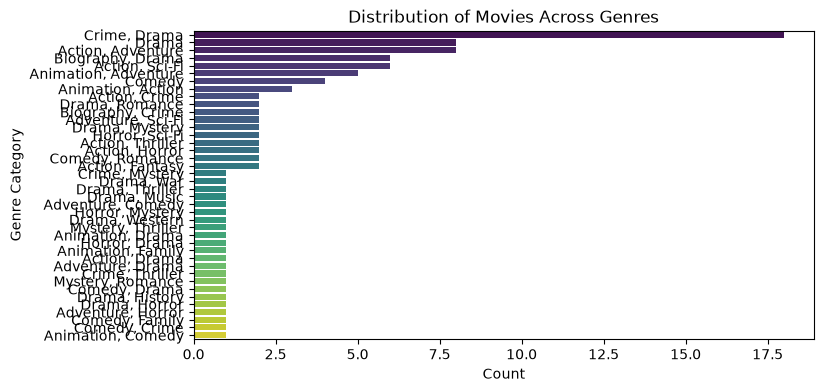

In [6]:
### CELL - 5 ###

# Step 5: Data Graph - Movie Genre Distribution Count
plt.figure(figsize=(8, 4))
sns.countplot(y='genre', data=df, order=df['genre'].value_counts().index, palette='viridis')
plt.title('Distribution of Movies Across Genres')
plt.xlabel('Count')
plt.ylabel('Genre Category')
plt.show()

In [7]:
### CELL - 6 ###

# Step 6: Separate text reviews (X) from target classifications (y)
# Note: Adjust column names ('review', 'sentiment') to match your sheet exactly
X = df['review']
y = df['sentiment']

print("Features Shape (Text Inputs):", X.shape)
print("Labels Shape (Target Outputs):", y.shape)

Features Shape (Text Inputs): (100,)
Labels Shape (Target Outputs): (100,)


In [8]:
### CELL - 7 ###

# Step 7: Train-Test Split partition
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Sample Count: {len(X_train)}")
print(f"Testing Sample Count: {len(X_test)}")

Training Sample Count: 80
Testing Sample Count: 20


In [9]:
### CELL - 8 ###

# Step 8: Initialize text feature extractor
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform training sequences, transform test strings
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vocabulary Array Dimensions Matrix:", X_train_tfidf.shape)

Vocabulary Array Dimensions Matrix: (80, 474)


In [10]:
### CELL - 9 ###

# Step 9: Initialize Logistic Regression Classifier and Fit Parameters
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

print("Model Training Routine Completed Successfully!")

Model Training Routine Completed Successfully!


In [11]:
### CELL - 10 ###

# Step 10: Test pipeline predictions evaluation
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Testing Accuracy: {accuracy * 100:.2f}%\n")
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

Overall Testing Accuracy: 85.00%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.85      1.00      0.92        17

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20



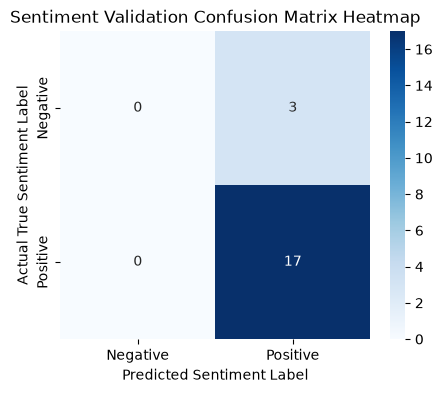

In [12]:
### CELL - 11 ###

# Step 11: Confusion Matrix Visualization Heatmap
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Sentiment Validation Confusion Matrix Heatmap')
plt.xlabel('Predicted Sentiment Label')
plt.ylabel('Actual True Sentiment Label')
plt.show()

In [13]:
### CELL - 12 ###

# Step 12: Export trained model binaries and save database backup for the Streamlit app
joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump(model, 'sentiment_model.pkl')

# Save dataset snapshot as a clean CSV for the application recommendations lookup
df.to_csv('movies_dataset.csv', index=False)

print("Successfully exported vectorizer.pkl, sentiment_model.pkl, and movies_dataset.csv to disk!")

Successfully exported vectorizer.pkl, sentiment_model.pkl, and movies_dataset.csv to disk!
